In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.io.arff import loadarff

sns.set_theme(style="whitegrid")
df = pd.DataFrame(loadarff("people_data.arff")[0])

df.info()
pd.set_option("display.max_colwidth", None)
for col in df.select_dtypes("object").columns:
    df[col] = df[col].str.decode("utf-8").replace("?", np.nan)

missing = df.isna().sum()
missing[missing > 0].sort_values(ascending=False)

<class 'pandas.DataFrame'>
RangeIndex: 48842 entries, 0 to 48841
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             48842 non-null  float64
 1   workclass       48842 non-null  object 
 2   fnlwgt          48842 non-null  float64
 3   education       48842 non-null  object 
 4   education-num   48842 non-null  float64
 5   marital-status  48842 non-null  object 
 6   occupation      48842 non-null  object 
 7   relationship    48842 non-null  object 
 8   race            48842 non-null  object 
 9   sex             48842 non-null  object 
 10  capital-gain    48842 non-null  float64
 11  capital-loss    48842 non-null  float64
 12  hours-per-week  48842 non-null  float64
 13  native-country  48842 non-null  object 
 14  class           48842 non-null  object 
dtypes: float64(6), object(9)
memory usage: 5.6+ MB


occupation        2809
workclass         2799
native-country     857
dtype: int64

count    48842.000000
mean        38.643585
std         13.710510
min         17.000000
25%         28.000000
50%         37.000000
75%         48.000000
max         90.000000
Name: age, dtype: float64
skew: 0.5575803166133181


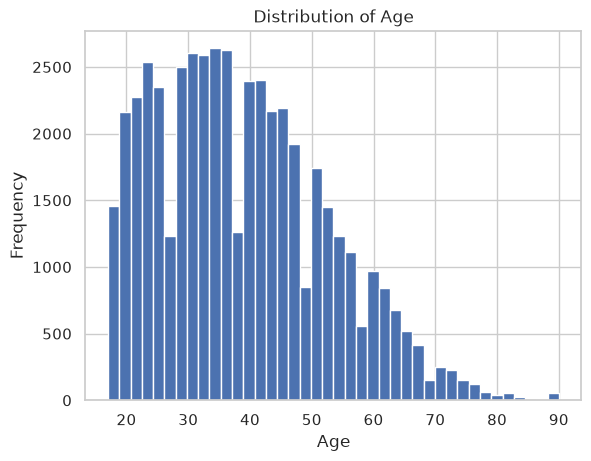

In [32]:
print(df["age"].describe())
print("skew:", df["age"].skew())

plt.title("Distribution of Age")
plt.xlabel("Age")
plt.ylabel("Frequency")
df["age"].hist(bins=40)
plt.show()

count    48842.000000
mean        40.422382
std         12.391444
min          1.000000
25%         40.000000
50%         40.000000
75%         45.000000
max         99.000000
Name: hours-per-week, dtype: float64
skew: 0.2387496572027575
hours-per-week
40.0    22803
50.0     4246
45.0     2717
60.0     2177
35.0     1937
20.0     1862
30.0     1700
55.0     1051
25.0      958
48.0      770
Name: count, dtype: int64


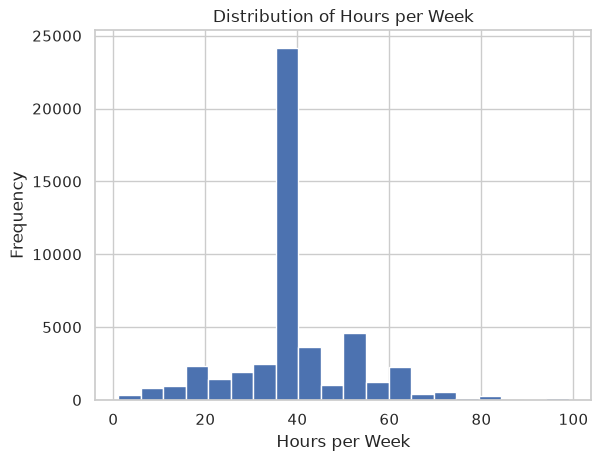

In [33]:
print(df["hours-per-week"].describe())
print("skew:", df["hours-per-week"].skew())
print(df["hours-per-week"].value_counts().head(10))

plt.title("Distribution of Hours per Week")
plt.xlabel("Hours per Week")
plt.ylabel("Frequency")
df["hours-per-week"].hist(bins=20)
plt.show()

education
Preschool        1.0
1st-4th          2.0
5th-6th          3.0
7th-8th          4.0
9th              5.0
10th             6.0
11th             7.0
12th             8.0
HS-grad          9.0
Some-college    10.0
Assoc-voc       11.0
Assoc-acdm      12.0
Bachelors       13.0
Masters         14.0
Prof-school     15.0
Doctorate       16.0
Name: education-num, dtype: float64


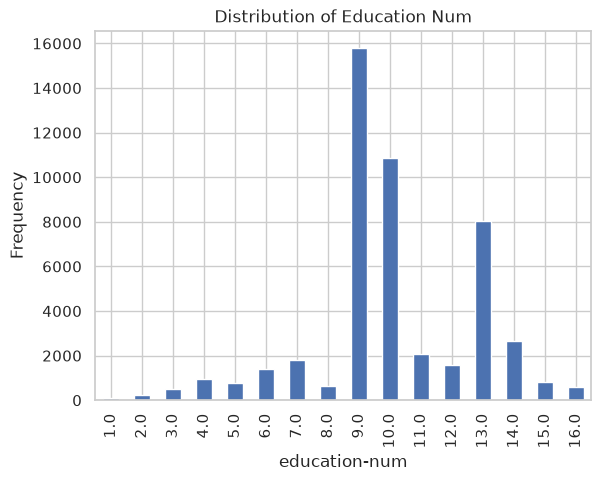

In [34]:
print(df.groupby("education")["education-num"].first().sort_values())

plt.title("Distribution of Education Num")
plt.xlabel("Education Num")
plt.ylabel("Frequency")
df["education-num"].value_counts().sort_index().plot(kind="bar")
plt.show()

In [35]:
for col in ["occupation", "workclass", "relationship", "marital-status", "race", "sex", "native-country"]:
    print(df[col].value_counts())
    print((df[col].value_counts(normalize=True).mul(100).round(2).astype(str) + "%"))

    print("------------------------")

occupation
Prof-specialty       6172
Craft-repair         6112
Exec-managerial      6086
Adm-clerical         5611
Sales                5504
Other-service        4923
Machine-op-inspct    3022
Transport-moving     2355
Handlers-cleaners    2072
Farming-fishing      1490
Tech-support         1446
Protective-serv       983
Priv-house-serv       242
Armed-Forces           15
Name: count, dtype: int64
occupation
Prof-specialty       13.41%
Craft-repair         13.28%
Exec-managerial      13.22%
Adm-clerical         12.19%
Sales                11.96%
Other-service        10.69%
Machine-op-inspct     6.56%
Transport-moving      5.12%
Handlers-cleaners      4.5%
Farming-fishing       3.24%
Tech-support          3.14%
Protective-serv       2.14%
Priv-house-serv       0.53%
Armed-Forces          0.03%
Name: proportion, dtype: str
------------------------
workclass
Private             33906
Self-emp-not-inc     3862
Local-gov            3136
State-gov            1981
Self-emp-inc         1695
Fe

In [36]:
print(df["class"].value_counts(normalize=True))
print((df["class"].value_counts(normalize=True).mul(100).round(2).astype(str) + "%"))

class
<=50K    0.760718
>50K     0.239282
Name: proportion, dtype: float64
class
<=50K    76.07%
>50K     23.93%
Name: proportion, dtype: str


# put analysis here

In [37]:
from apriori_from_scratch import apriori

items = df.drop(columns=["fnlwgt", "education-num"])

items["age"] = pd.cut(df["age"], bins=[0, 25, 35, 45, 55, 65, 100], right=False,
                      labels=["<25", "25-34", "35-44", "45-54", "55-64", "65+"])
items["hours-per-week"] = pd.cut(df["hours-per-week"], bins=[0, 35, 41, 100], right=False,
                                 labels=["part-time", "full-time", "overtime"])
items["capital-gain"] = np.where(df["capital-gain"] > 0, "yes", None)
items["capital-loss"] = np.where(df["capital-loss"] > 0, "yes", None)

transactions = [
    {f"{col}={val}" for col, val in row.items() if pd.notna(val)}
    for row in items.to_dict("records")
]
transactions[0]

{'age=25-34',
 'class=<=50K',
 'education=11th',
 'hours-per-week=full-time',
 'marital-status=Never-married',
 'native-country=United-States',
 'occupation=Machine-op-inspct',
 'race=Black',
 'relationship=Own-child',
 'sex=Male',
 'workclass=Private'}

In [38]:
rules = apriori(transactions, min_frequency=int(0.05 * len(transactions)))
rules = pd.DataFrame(rules, columns=["antecedent", "consequent", "support", "confidence", "lift"])
rules = rules[rules["consequent"].str.len() == 1]

print(len(rules))

10573


In [39]:
rules[(rules["confidence"] > 0.6) & (rules["lift"] > 1.5)].sort_values("lift", ascending=False).head(20)

,antecedent,consequent,support,confidence,lift
44296,"(class=<=50K, hours-per-week=part-time, marital-status=Never-married, native-country=United-States, relationship=Own-child)","(age=<25,)",0.050489,0.897380,5.198035
23295,"(hours-per-week=part-time, marital-status=Never-married, native-country=United-States, relationship=Own-child)","(age=<25,)",0.050551,0.897166,5.196794
17324,"(class=<=50K, hours-per-week=part-time, marital-status=Never-married, relationship=Own-child)","(age=<25,)",0.053294,0.896041,5.190281
15546,"(hours-per-week=part-time, marital-status=Never-married, relationship=Own-child)","(age=<25,)",0.053376,0.895876,5.189325
34904,"(class=<=50K, hours-per-week=part-time, native-country=United-States, relationship=Own-child)","(age=<25,)",0.051124,0.871249,5.046673
16820,"(hours-per-week=part-time, native-country=United-States, relationship=Own-child)","(age=<25,)",0.051185,0.870171,5.040426
10184,"(class=<=50K, hours-per-week=part-time, relationship=Own-child)","(age=<25,)",0.053990,0.869436,5.036172
4356,"(hours-per-week=part-time, relationship=Own-child)","(age=<25,)",0.054072,0.868179,5.028889
44290,"(age=<25, class=<=50K, hours-per-week=part-time, marital-status=Never-married, native-country=United-States)","(relationship=Own-child,)",0.050489,0.769663,4.958696
23292,"(age=<25, hours-per-week=part-time, marital-status=Never-married, native-country=United-States)","(relationship=Own-child,)",0.050551,0.769159,4.955449


In [40]:
print(rules[rules["consequent"] == ("class=>50K",)].sort_values("confidence", ascending=False).head(15))
print(rules[rules["consequent"] == ("class=<=50K",)].sort_values("confidence", ascending=False).head(15))

                                                                                       antecedent  \
13929      (education=Bachelors, marital-status=Married-civ-spouse, native-country=United-States)   
2395                              (marital-status=Married-civ-spouse, occupation=Exec-managerial)   
12934                        (education=Bachelors, marital-status=Married-civ-spouse, race=White)   
10401                                       (education=Bachelors, relationship=Husband, sex=Male)   
846                                                   (education=Bachelors, relationship=Husband)   
29295    (education=Bachelors, marital-status=Married-civ-spouse, relationship=Husband, sex=Male)   
7055               (education=Bachelors, marital-status=Married-civ-spouse, relationship=Husband)   
13957                          (education=Bachelors, marital-status=Married-civ-spouse, sex=Male)   
1368                                     (education=Bachelors, marital-status=Married-civ-s

# analysis here

In [41]:
df["high_income"] = (df["class"] == ">50K").astype(int)

              count      mean
education                    
10th           1389  0.062635
11th           1812  0.050773
12th            657  0.073059
1st-4th         247  0.032389
5th-6th         509  0.053045
7th-8th         955  0.064921
9th             756  0.054233
Assoc-acdm     1601  0.257964
Assoc-voc      2061  0.253275
Bachelors      8025  0.412835
Doctorate       594  0.725589
HS-grad       15784  0.158578
Masters        2657  0.549116
Preschool        83  0.012048
Prof-school     834  0.739808
Some-college  10878  0.189649


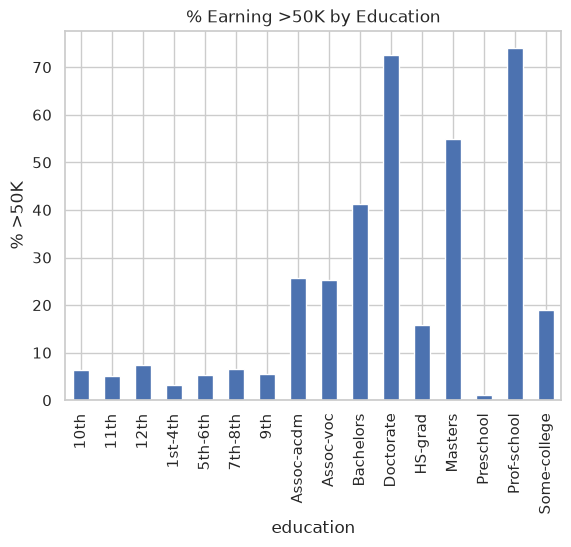

In [43]:
print(df.groupby("education")["high_income"].agg(["count", "mean"]))

plt.title("% Earning >50K by Education")
plt.xlabel("Education")
plt.ylabel("% >50K")
df.groupby("education")["high_income"].mean().mul(100).plot(kind="bar")
plt.show()

class                  <=50K  >50K
marital-status                    
Divorced                89.9  10.1
Married-AF-spouse       62.2  37.8
Married-civ-spouse      55.4  44.6
Married-spouse-absent   90.8   9.2
Never-married           95.5   4.5
Separated               93.5   6.5
Widowed                 91.6   8.4


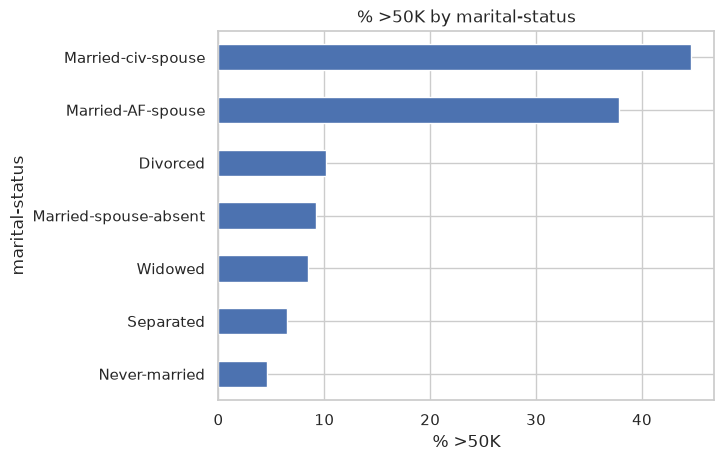

class           <=50K  >50K
relationship               
Husband          55.1  44.9
Not-in-family    89.9  10.1
Other-relative   96.5   3.5
Own-child        98.5   1.5
Unmarried        94.0   6.0
Wife             53.1  46.9


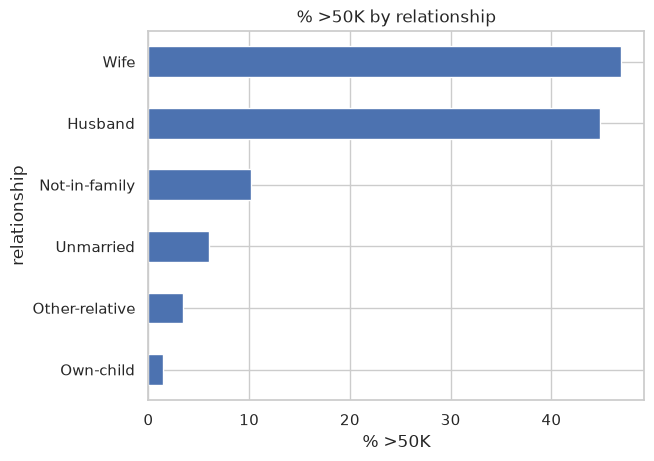

In [45]:
for col in ["marital-status", "relationship"]:
    print(pd.crosstab(df[col], df["class"], normalize="index").mul(100).round(1))
    df.groupby(col)["high_income"].mean().mul(100).sort_values().plot(kind="barh")
    plt.title(f"% >50K by {col}")
    plt.xlabel("% >50K")
    plt.show()

In [46]:
print(pd.crosstab(df["relationship"], df["sex"]))
print(pd.crosstab(df["sex"], df["class"], normalize="index").mul(100).round(1))

sex             Female   Male
relationship                 
Husband              1  19715
Not-in-family     5870   6713
Other-relative     689    817
Own-child         3376   4205
Unmarried         3928   1197
Wife              2328      3
class   <=50K  >50K
sex                
Female   89.1  10.9
Male     69.6  30.4
